# 6. The Laplacian Pyramid

In [20]:
#%matplotlib widget
import warnings
#import inspect
import matplotlib.pyplot as plt
import IPython.display
import numpy as np
from cued_sf2_lab.familiarisation import load_mat_img, plot_image

## 6.1 The basic concept

<figure id="figure-2">
<div style="background-color: white">

![](figures/laplacian.svg)</div>
    
<figcaption style="text-align: center">Figure 2: A typical laplacian pyramid with 2 levels; forward (analysis) part only</figcaption>
</figure>

The Laplacian pyramid is an energy compaction technique, based on
the observation:

> For most real-world images, the high-frequency energy is much less than the low-frequency energy.

Since the lowpass image is much lower bandwidth than the
original image, it can be subsampled (*decimated*) 2:1 in both
horizontal and vertical directions, without significant loss of
information to give a quarter-size lowpass image.  We have
provided a row filter/decimation function, `rowdec(X, h)`, to
filter and decimate the rows of a matrix by 2:1.

In [21]:
from cued_sf2_lab.laplacian_pyramid import rowdec

Use this twice
(on the image and its transpose) to generate a quarter-size
lowpass image `X1` of Lighthouse.  For simplicity use a 3-tap (length 3)
filter `h` with coefficients: $\frac{1}{4} [1\ 2\ 1]$.

In [22]:
X, cmaps_dict = load_mat_img(img='lighthouse.mat', img_info='X', cmap_info={'map', 'map2'})

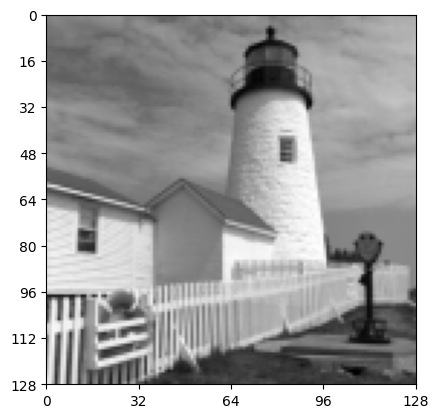

In [59]:
h = 0.25*np.array([1, 2, 1])
X1 = rowdec(rowdec(X,h).T,h).T
fig, ax = plt.subplots()
plot_image(X1,ax=ax)
  # your code here

The image `X1` can be interpolated 2:1 in each direction to
generate a lowpass image of the original size, which can then be
subtracted from the original to yield a full-size highpass image.
We have also provided a row interpolation/filter function,
`rowint(X, h)`, which doubles the length of each row of the image, by
inserting zeros between alternate samples and then lowpass
filtering the result with the filter `h`. Note that to undo the decimation
performed by `Y = rowdec(X, h)`, this should be called as `Z = rowint(Y, 2*h)`,
where a DC gain of 2 is added, as shown in [Figure 2](#figure-2).

In [60]:
from cued_sf2_lab.laplacian_pyramid import rowint

Apply this twice (as before) to generate
a full-size lowpass image, and subtract this from `X` to
give a highpass image `Y0`. Display `X1` and `Y0` to see these effects.

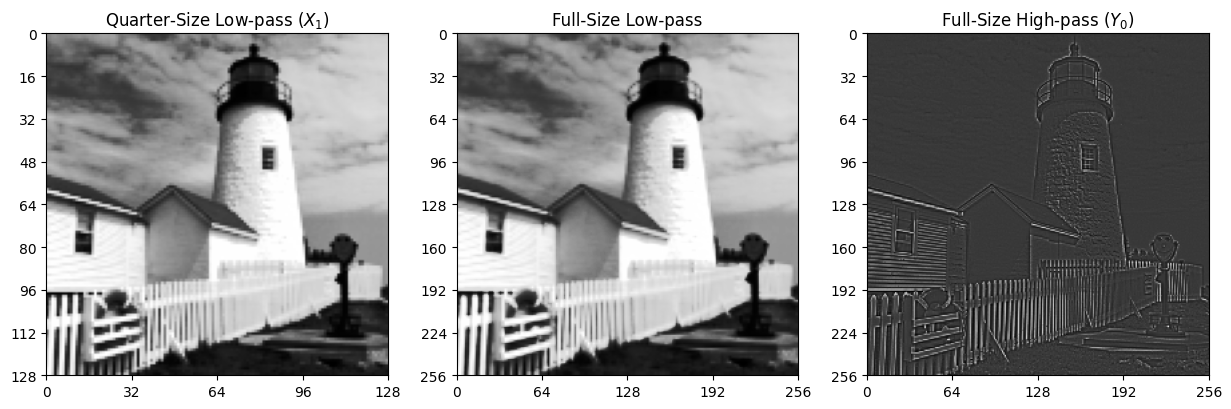

In [61]:
# 1. Interpolate the rows, transpose, interpolate the columns, transpose back
# 2*h scales the DC gain correctly to compensate for the inserted zeros
X_lowpass_full = rowint(rowint(X1, 2*h).T, 2*h).T

# 2. Subtract the full-size lowpass image from the original image to isolate high frequencies
Y0 = X - X_lowpass_full


# 3. Create a side-by-side layout with exactly 1 row and 3 columns
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: The small quarter-size low-pass base image (128x128)
ax1.set_title("Quarter-Size Low-pass ($X_1$)")
plot_image(X1, ax=ax1, cmap=cmaps_dict['map2'])

# Plot 2: The upsampled full-size low-pass image (256x256)
ax2.set_title("Full-Size Low-pass")
plot_image(X_lowpass_full, ax=ax2, cmap=cmaps_dict['map2'])

# Plot 3: The isolated high-frequency detail image (256x256)
ax3.set_title("Full-Size High-pass ($Y_0$)")
plot_image(Y0, ax=ax3, cmap=cmaps_dict['map2'])

plt.show()

The highpass images will
always have approximately zero mean (since any dc component is
removed). Hence for the remainder of this project, we recommend
that you also make all lowpass images be approximately zero mean
by subtracting 128 from them before you start any processing. This
makes the 8-bit pixel values cover the range -128 to 127,
instead of 0 to 255. The advantages of having a zero-mean input image are not very obvious here, but they
will become clearer as the project progresses. If you use `draw_image` the images will still be displayed correctly.

In [26]:
X, cmaps_dict = load_mat_img(img='lighthouse.mat', img_info='X', cmap_info={'map', 'map2'})
X = X - 128.0

Examine the functions ```rowdec``` and ```rowint``` and check that you understand how they work. Decimation is achieved by selecting every second element of a vector using selection indices `i:i+c:2`, and filtering is performed with symmetric extension as in ```convse```, except that we do not bother to calculate the filter outputs that are to be discarded by the decimation process. Interpolation is achieved by loading every second element of a double-size vector using `X2 = np.zeros((r, c2), dtype=X.dtype)`, `X2[:, ::2] = X`. The intermediate samples of the interpolated vector x must be zero before the vector is passed through the interpolation filter.

In [27]:
IPython.display.Code(inspect.getsource(rowdec), language="python")

NameError: name 'inspect' is not defined

In [ ]:
IPython.display.Code(inspect.getsource(rowint), language="python")

def rowint(X: np.ndarray, h: np.ndarray) -> np.ndarray:
    """
    Interpolates the rows of image X by 2 using h.

    Parameters:
        X: Image matrix (Usually 256x256)
        h: Filter coefficients
    Returns:
        Y: Image with interpolated rows

    If len(h) is odd, each input sample is aligned with the first of
    each pair of output samples.
    If len(h) is even, each input sample is aligned with the mid point
    of each pair of output samples.
    """
    r, c = X.shape
    m = len(h)
    m2 = m // 2
    c2 = 2 * c

    # Generate X2 as X interleaved with columns of zeros.
    X2 = np.zeros((r, c2), dtype=X.dtype)
    X2[:, ::2] = X

    X2 = np.pad(X2, [(0, 0), (m2, m2)], mode='reflect' if m % 2 else 'symmetric')

    Y = np.zeros((r, c2))
    # Loop for each term in h.
    for i in range(m):
        Y = Y + h[i] * X2[:, i:i+c2]
    return Y

If the small lowpass image `X1` and the full-size highpass image `Y0`
are transmitted to a distant decoder, then the decoder can exactly reconstruct
the original image by interpolating `X1` up to full size and adding in
`Y0` (which represents the error between the original and the interpolated
`X1`).  We have achieved image compression if `X1` and `Y0` can be
transmitted with fewer bits than `X`.  Usually this will be the case
because `Y0` contains so much less energy than `X`, and `X1` is
only one quarter of the size of `X`.  However we do start at a
disadvantage because there are 25% more samples to code.  Many of the `Y0` samples may be represented by zero, and we shall show later that runs of
zeros may be coded with relatively few bits.

The quarter-size lowpass image `X1` may be further subsampled, using the
same process as was applied to `X`, so that it may be transmitted as a
one-sixteenth-size lowpass image `X2` and a quarter-size highpass image
`Y1`.  This usually achieves further data compression and may be repeated
as many times as is desired (until, for typical images, no further compression
is achieved).  This leads to a pyramid of highpass images and a final tiny
lowpass image.  Usually three or four layers of the pyramid are sufficient to
give maximum compression.

Write a `py4enc(X, h)` function to generate a 4-layer pyramid, so that `X` is split into four
highpass images, `Y0 Y1 Y2 Y3`, each a quarter of the size of its predecessor, plus a tiny
lowpass image `X4`, which is a quarter of the size of `Y3`.

In [28]:
def py4enc(X, h):
    """
    Generates a 4-layer Laplacian pyramid.
    Splits image X into 4 highpass images (Y0, Y1, Y2, Y3) and a tiny lowpass base (X4).
    """
    # Layer 0 -> Layer 1
    X1 = rowdec(rowdec(X, h).T, h).T
    Y0 = X - rowint(rowint(X1, 2*h).T, 2*h).T
    
    # Layer 1 -> Layer 2
    X2 = rowdec(rowdec(X1, h).T, h).T
    Y1 = X1 - rowint(rowint(X2, 2*h).T, 2*h).T
    
    # Layer 2 -> Layer 3
    X3 = rowdec(rowdec(X2, h).T, h).T
    Y2 = X2 - rowint(rowint(X3, 2*h).T, 2*h).T
    
    # Layer 3 -> Layer 4
    X4 = rowdec(rowdec(X3, h).T, h).T
    Y3 = X3 - rowint(rowint(X4, 2*h).T, 2*h).T

    return Y0, Y1, Y2, Y3, X4

We can then plot the results to check them using the `beside` helper function:

In [29]:
from cued_sf2_lab.laplacian_pyramid import beside

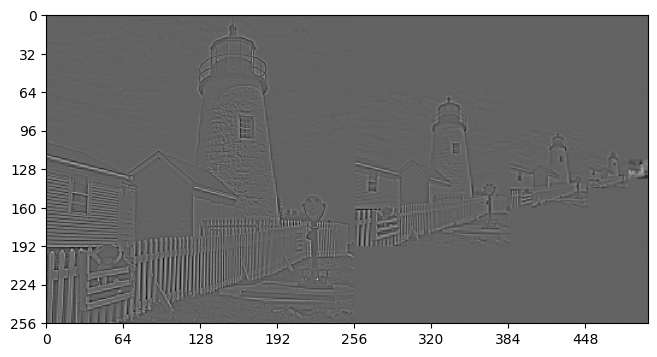

In [30]:
Y0, Y1, Y2, Y3, X4 = py4enc(X, h)
fig, ax = plt.subplots(figsize=(8, 4))
plot_image(beside(Y0, beside(Y1, beside(Y2, beside(Y3, X4)))), ax=ax);

If we wish to see the images separately from each other, instead of using our `beside` function that was written to match the old Matlab version, we can draw this directly with `matplotlib` using [`plt.subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) to create a set of subplots, and the `width_ratios` argument to [`GridSpec`](https://matplotlib.org/stable/api/_as_gen/matplotlib.gridspec.GridSpec.html):

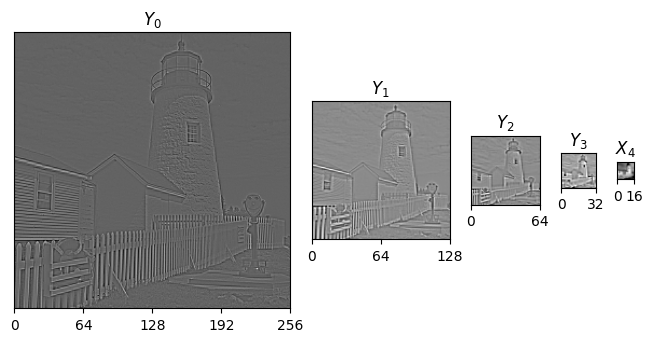

In [31]:
titles = ["Y_0", "Y_1", "Y_2", "Y_3", "X_4"]
imgs = [Y0, Y1, Y2, Y3, X4]
fig, axs = plt.subplots(1, 5, figsize=(8, 4),
                        gridspec_kw=dict(width_ratios=[img.shape[0] for img in imgs]))

for ax, img, title in zip(axs, imgs, titles):
    plot_image(img, ax=ax)
    ax.set(yticks=[], title=f'${title}$')

If we wish to see the images at the same scale as each other, we can use:

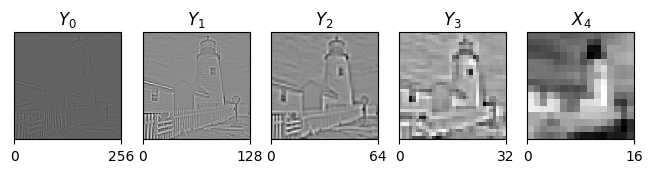

In [32]:
titles = ["Y_0", "Y_1", "Y_2", "Y_3", "X_4"]
imgs = [Y0, Y1, Y2, Y3, X4]
fig, axs = plt.subplots(1, 5, figsize=(8, 2))

for ax, img, title in zip(axs, imgs, titles):
    plot_image(img, ax=ax)
    ax.set(yticks=[], title=f'${title}$')

Get a demonstrator to check that your images look correct, and
then write another function `py4dec` to decode `X4` and
`Y3 Y2 Y1 Y0` into a set of lowpass images `Z3 Z2 Z1 Z0`.
(`Z3` is obtained by interpolating `X4` and adding
`Y3`, and then `Z2` is obtained from `Z3` and `Y2`, and
so on.)

In [33]:
def py4dec(Y0, Y1, Y2, Y3, X4, h):
    """
    Decodes a 4-layer Laplacian pyramid.
    Reconstructs the pyramid levels Z3, Z2, Z1, and the final image Z0
    using highpass layers (Y0, Y1, Y2, Y3) and lowpass base X4.
    """
    # Z3 is obtained by interpolating X4 and adding Y3
    Z3 = rowint(rowint(X4, 2*h).T, 2*h).T + Y3
    
    # Z2 is obtained by interpolating Z3 and adding Y2
    Z2 = rowint(rowint(Z3, 2*h).T, 2*h).T + Y2
    
    # Z1 is obtained by interpolating Z2 and adding Y1
    Z1 = rowint(rowint(Z2, 2*h).T, 2*h).T + Y1
    
    # Z0 is obtained by interpolating Z1 and adding Y0
    Z0 = rowint(rowint(Z1, 2*h).T, 2*h).T + Y0

    return Z3, Z2, Z1, Z0

If all is correct, `Z0` should be identical to
`X`.  You can check that your function is correct by calculating `np.max(abs(X - Z0))` and also displaying your pyramid of decoded images, `Z3` to `Z0`.

Encode-Decode Error = 0.0


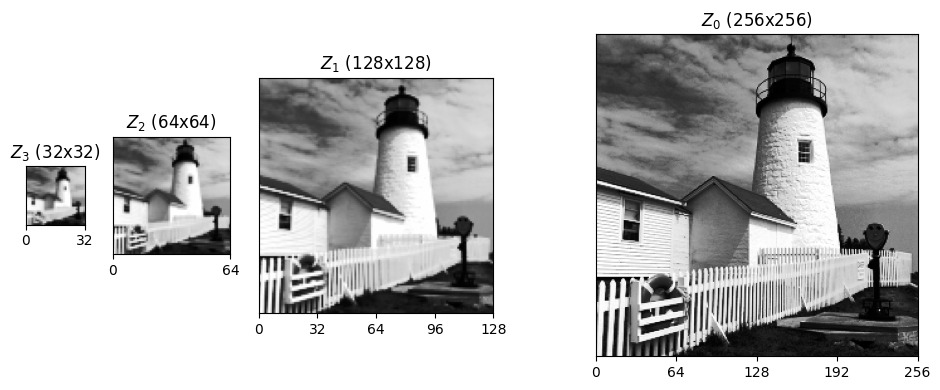

In [34]:
h = 0.25*np.array([1, 2, 1])
Z3, Z2, Z1, Z0 = py4dec(Y0, Y1, Y2, Y3, X4, h)
encode_decode_err = np.max(np.abs(X - Z0))
print(f'Encode-Decode Error = {encode_decode_err}')

# your code here to plot the images
Z3, Z2, Z1, Z0 = py4dec(Y0, Y1, Y2, Y3, X4, h)

# 3. Gather our images and titles for the plot
titles = ["Z_3", "Z_2", "Z_1", "Z_0"]
imgs = [Z3, Z2, Z1, Z0]

# 4. Create subplots where the layout width matches the image pixel ratios
fig, axs = plt.subplots(1, 4, figsize=(10, 4),
                        gridspec_kw=dict(width_ratios=[img.shape[0] for img in imgs]))

# 5. Loop through and display each decoded layer
for ax, img, title in zip(axs, imgs, titles):
    plot_image(img, ax=ax, cmap=cmaps_dict['map2'])
    ax.set(yticks=[], title=f'${title}$ ({img.shape[0]}x{img.shape[1]})')

plt.tight_layout()
plt.show()

For further information on the Laplacian Pyramid see Burt and Adelson [IEEE Trans. on Communications, 1983, vol 31, no 4, pp 532-540, "The Laplacian Pyramid as a compact image code"].

## 6.2 Quantisation and Coding Efficiency
To see whether data compression is possible using the above pyramid decomposition, we must calculate the approximate number of bits required to code the image pyramid. This may be done using the *entropy* of the quantised image data. 

The entropy of a single data sample, whcih may randomly take one of $Q$ possible quantised values such that each value $q(i)$ has a probability $p(i)$ of being in state $i$ for $i=1\to Q$ is given by:

$$ \text{Entropy (bits/sample)} = \sum_{i=1}^Qp(i) \log_2\frac{1}{p(i)} = -\sum_{i=1}^Q p(i) \log_2p(i)$$

The entropy represents the minimum average number of bits per sample needed to code samples with the given probability distribution $p(i)$, assuming that an ideal variable-length entropy code is used, and that the samples are uncorrelated with each other. Arithmetic codes can get arbitrarily close to this bit rate, and simpler Huffman codes can also get vary close with many typical signals (you will be using Huffman codes later on). It is possible to code signals at bit rates less than the entropy, if the samples are correlated, but for simplicity we shall ignore this here.

To demonstrate the validity of the above formula, first consider a signal with 8 quantised values of equal probability $p(i) = 1/8$ for all $i$. The entropy is then $8 \times 1/8 \times \log_2(8) = 3$ bits per sample, as expected. 

Now consider a signal with only 3 values, with probabilities $p(1)=1/2$,  $p(2) = p(3) = 1/4$. The entropy is then $\frac{1}{2} \log_2(2) + 2 \times \frac{1}{4} \log_2(4) = 1.5$ bits per sample. This is consistent with using a single bit '0' to represent state 1 and two bits, '10' and '11' to represent states 2 and 3.

The function `bpp` has been written to calculate the entropy in bits per pixel of an image matrix `X`. First the function computes a histogram of `X` to determine the probabilities $p(i)$ and then it calculates the entropy, using the above formula.

In [35]:
from cued_sf2_lab.laplacian_pyramid import bpp

In the Laplacian Pyramid, the total number of bits is obtained by multiplying each of the sub-image entropies by the number of pixels in each corresponding sub-image. However, in order to compress the data, we also need to quantise the images. We have also provided a function `quantise` which will quantise `X` in steps centred on integer multiples of `step`. Hence `bpp(quantise(X, step))` will return the entropy of image `X` quantised in steps of `step`.

In [36]:
from cued_sf2_lab.laplacian_pyramid import quantise

<div class="alert alert-block alert-danger">

Calculate the entropies of images `X` `X1` `Y0` and hence the total numbers of bits to encode `X`, or `X1` and `Y0`, when quantised to a step size of 17 (which gives 15 distict grey levels if applied to a lowpass image with intensities from -127 to 127. Find the data compression for this simple one-stage pyramid, and then investigate the improvements from using more layers.
</div>

In [62]:
# Write your code to calculate compression ratios here.
# Ensure your image has a zero mean (-128 to 127) as recommended in the notebook
# X = X - 128.0  <-- Make sure this was run once previously

step = 17
h = 0.25 * np.array([1, 2, 1])

# ==========================================
# 1. REFERENCE SCHEME (Direct Quantisation)
# ==========================================
X_q = quantise(X, step)
entropy_X = bpp(X_q)
total_bits_ref = X.size * entropy_X

print(f"--- Reference Scheme (Direct Quantisation with step={step}) ---")
print(f"  Original X Entropy : {entropy_X:.4f} bits/pixel")
print(f"  Total Reference Bits: {total_bits_ref:.1f} bits\n")

# ==========================================
# 2. ONE-STAGE PYRAMID SCHEME (X1 and Y0)
# ==========================================
# Generate 1-stage components
X1 = rowdec(rowdec(X, h).T, h).T
Y0 = X - rowint(rowint(X1, 2*h).T, 2*h).T

# Quantise both components
X1_q = quantise(X1, step)
Y0_q = quantise(Y0, step)

# Calculate individual layer bits
bits_X1 = X1.size * bpp(X1_q)
bits_Y0 = Y0.size * bpp(Y0_q)
total_bits_1stage = bits_X1 + bits_Y0
cr_1stage = total_bits_ref / total_bits_1stage

print(f"--- Simple One-Stage Pyramid Scheme ---")
print(f"  Low-pass X1 Entropy: {bpp(X1_q):.4f} bits/pixel (Size: {X1.shape})")
print(f"  High-pass Y0 Entropy: {bpp(Y0_q):.4f} bits/pixel (Size: {Y0.shape})")
print(f"  Total 1-Stage Bits : {total_bits_1stage:.1f} bits")
print(f"  Compression Ratio   : {cr_1stage:.3f}\n")

# ==========================================
# 3. FOUR-STAGE PYRAMID SCHEME (Y0, Y1, Y2, Y3, X4)
# ==========================================
# Use the py4enc function we wrote in the previous section
# Quantise all components
Y0_q, Y1_q, Y2_q, Y3_q, X4_q = [quantise(img, step) for img in [Y0, Y1, Y2, Y3, X4]]

# Calculate entropies for each layer
ent_Y0 = bpp(Y0_q)
ent_Y1 = bpp(Y1_q)
ent_Y2 = bpp(Y2_q)
ent_Y3 = bpp(Y3_q)
ent_X4 = bpp(X4_q)

# Sum up total bits across every single scaled sub-image
total_bits_4stage = (Y0.size * ent_Y0 + 
                     Y1.size * ent_Y1 + 
                     Y2.size * ent_Y2 + 
                     Y3.size * ent_Y3 + 
                     X4.size * ent_X4)

cr_4stage = total_bits_ref / total_bits_4stage

print(f"--- Full 4-Stage Pyramid Scheme ---")
print(f"  Layer Y0 Entropy: {ent_Y0:.4f} bits/pixel (Size: {Y0.shape})")
print(f"  Layer Y1 Entropy: {ent_Y1:.4f} bits/pixel (Size: {Y1.shape})")
print(f"  Layer Y2 Entropy: {ent_Y2:.4f} bits/pixel (Size: {Y2.shape})")
print(f"  Layer Y3 Entropy: {ent_Y3:.4f} bits/pixel (Size: {Y3.shape})")
print(f"  Layer X4 Entropy: {ent_X4:.4f} bits/pixel (Size: {X4.shape})")
print(f"  -----------------------------------")
print(f"  Total 4-Stage Bits : {total_bits_4stage:.1f} bits")
print(f"  Compression Ratio  : {cr_4stage:.3f}")

--- Reference Scheme (Direct Quantisation with step=17) ---
  Original X Entropy : 3.4785 bits/pixel
  Total Reference Bits: 227964.1 bits

--- Simple One-Stage Pyramid Scheme ---
  Low-pass X1 Entropy: 3.4088 bits/pixel (Size: (128, 128))
  High-pass Y0 Entropy: 1.6208 bits/pixel (Size: (256, 256))
  Total 1-Stage Bits : 162072.9 bits
  Compression Ratio   : 1.407

--- Full 4-Stage Pyramid Scheme ---
  Layer Y0 Entropy: 1.6208 bits/pixel (Size: (256, 256))
  Layer Y1 Entropy: 1.3906 bits/pixel (Size: (128, 128))
  Layer Y2 Entropy: 1.4547 bits/pixel (Size: (64, 64))
  Layer Y3 Entropy: 1.5784 bits/pixel (Size: (32, 32))
  Layer X4 Entropy: 2.9873 bits/pixel (Size: (16, 16))
  -----------------------------------
  Total 4-Stage Bits : 137345.8 bits
  Compression Ratio  : 1.660


Since compressing an image will generally result in a reduction in quality, we also need a way to measure this quality reduction. It is actually quite hard to find a quality measure whcih matches individual perceptions of how an image has been changed due to compression, and for that reason it is important to always judge and comment on an image visually. However we also need a quantitative measure, and the most obvious is the rms error (standard deviation) between the input and compressed image (i.e. using ```np.std(X - Z)``` where `Z` is the compressed image).

<div class="alert alert-block alert-danger">
Quantise the Laplacian pyramid with a step size of 17, and reconstruct the output image from the decoding pyramid. Look at the visual features, and calculate the rms error (standard deviation) between the input image and the decoding pyramid output image. Repeat this for more layers in the pyramid.
</div>

RMS Error (1-Layer Pyramid): 5.3948
RMS Error (2-Layer Pyramid): 6.0126
RMS Error (4-Layer Pyramid): 7.5571


'axs[1, 0].set_title("1-Layer Error Residual ")\nplot_image((X - Z0_1layer) , ax=axs[1, 0], cmap=cmaps_dict[\'map2\'])\n\naxs[1, 1].set_title("2-Layer Error Residual ")\nplot_image((X - Z0_2layer) , ax=axs[1, 1], cmap=cmaps_dict[\'map2\'])\n\naxs[1, 2].set_title("4-Layer Error Residual ")\nplot_image((X - Z0_4layer), ax=axs[1, 2], cmap=cmaps_dict[\'map2\'])\n\nplt.tight_layout()\nplt.show()'

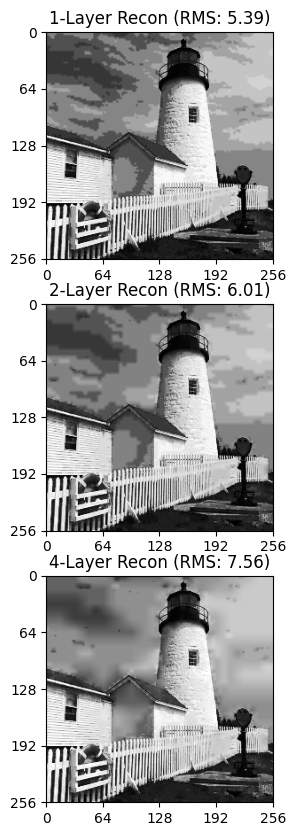

In [58]:
# Write your code to explore rms error with the laplacian pyramid here.
import numpy as np
import matplotlib.pyplot as plt

# Ensure X is zero-mean (-128.0 to 127.0)
X = X - 128.0  

step = 17
h = 0.25 * np.array([1, 2, 1])

# ==========================================================
# 1. Generate full 4-stage pyramid components
# ==========================================================
Y0, Y1, Y2, Y3, X4 = py4enc(X, h)

# ==========================================================
# 2. Evaluate Reconstruction Error vs. Pyramid Depth
# ==========================================================

# Case A: 1-Layer Pyramid (Send Y0 and X1)
X1 = rowdec(rowdec(X, h).T, h).T
X1_q = quantise(X1, step)
Y0_q = quantise(Y0, step)
Z0_1layer = rowint(rowint(X1_q, 2*h).T, 2*h).T + Y0_q
rms_1layer = np.std(X - Z0_1layer)

# Case B: 2-Layer Pyramid (Send Y0, Y1, and X2)
X2 = rowdec(rowdec(X1, h).T, h).T
X2_q = quantise(X2, step)
Y1_q = quantise(Y1, step)
Z1_2layer = rowint(rowint(X2_q, 2*h).T, 2*h).T + Y1_q
Z0_2layer = rowint(rowint(Z1_2layer, 2*h).T, 2*h).T + Y0_q
rms_2layer = np.std(X - Z0_2layer)

# Case C: 4-Layer Pyramid (Send Y0, Y1, Y2, Y3, and X4)
Y1_q, Y2_q, Y3_q, X4_q = quantise(Y1, step), quantise(Y2, step), quantise(Y3, step), quantise(X4, step)
Z3_4, Z2_4, Z1_4, Z0_4layer = py4dec(Y0_q, Y1_q, Y2_q, Y3_q, X4_q, h)
rms_4layer = np.std(X - Z0_4layer)

print(f"RMS Error (1-Layer Pyramid): {rms_1layer:.4f}")
print(f"RMS Error (2-Layer Pyramid): {rms_2layer:.4f}")
print(f"RMS Error (4-Layer Pyramid): {rms_4layer:.4f}")

# ==========================================================
# 3. Visualize the Reconstructed Images & Error Residuals
# ==========================================================
fig, axs = plt.subplots( 3, figsize=(15, 10))

# Top row: Reconstructed Images
axs[ 0].set_title(f"1-Layer Recon (RMS: {rms_1layer:.2f})")
plot_image(Z0_1layer, ax=axs[0], cmap=cmaps_dict['map2'])

axs[ 1].set_title(f"2-Layer Recon (RMS: {rms_2layer:.2f})")
plot_image(Z0_2layer, ax=axs[ 1], cmap=cmaps_dict['map2'])

axs[ 2].set_title(f"4-Layer Recon (RMS: {rms_4layer:.2f})")
plot_image(Z0_4layer, ax=axs[ 2], cmap=cmaps_dict['map2'])

########### Bottom row: Enhanced Error Images 
"""axs[1, 0].set_title("1-Layer Error Residual ")
plot_image((X - Z0_1layer) , ax=axs[1, 0], cmap=cmaps_dict['map2'])

axs[1, 1].set_title("2-Layer Error Residual ")
plot_image((X - Z0_2layer) , ax=axs[1, 1], cmap=cmaps_dict['map2'])

axs[1, 2].set_title("4-Layer Error Residual ")
plot_image((X - Z0_4layer), ax=axs[1, 2], cmap=cmaps_dict['map2'])

plt.tight_layout()
plt.show()"""

Note that we call this error the rms error, but in fact we calculate the standard deviation, which only equals the true rms error if the mean error is zero. However the eye is very insensitive to small errors in the mean level of images, so the standard deviation (which ignores the mean) is a better measure of image quality. 

<div class="alert alert-block alert-danger">
Quantise the original image with the same step size (17) and note the visual features and rms error. Compare these results from the pyramid scheme above. Why are the rms errors larger in the pyramid scheme? 
</div>

Direct Quantisation RMS Error (step=17): 4.8570
4-Layer Pyramid Recon RMS Error (step=17): 7.6278
Pyramid Error Increase Factor          : 1.57x


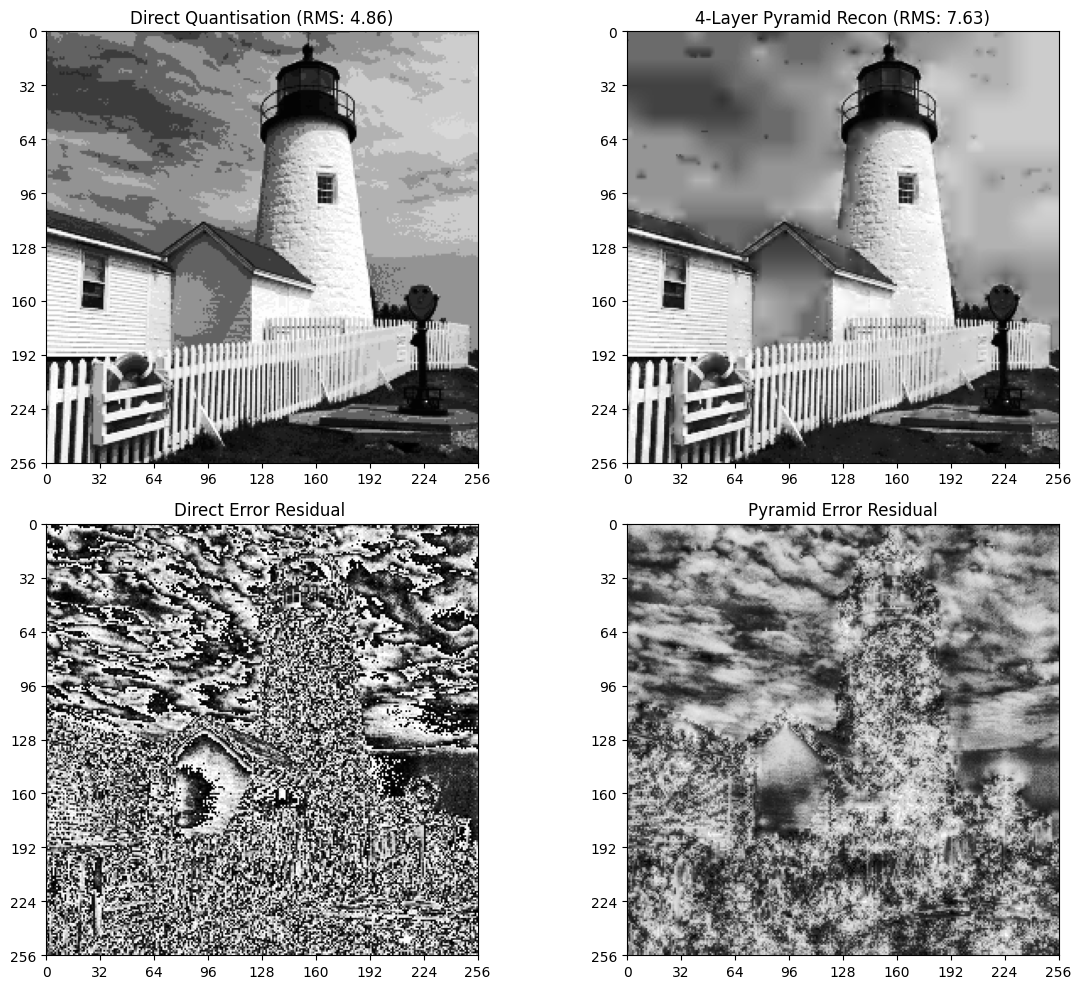

In [44]:
# Write your code to calculate the error from directly quantising the original
# image.
# Ensure X is zero-mean (-128.0 to 127.0)
X = X - 128.0  

step = 17
h = 0.25 * np.array([1, 2, 1])

# ==========================================================
# 1. Direct Quantisation (The Reference)
# ==========================================================
X_q = quantise(X, step)
rms_direct = np.std(X - X_q)

# ==========================================================
# 2. Reconstruct 4-Layer Pyramid for Comparison
# ==========================================================
Y0, Y1, Y2, Y3, X4 = py4enc(X, h)
Y0_q, Y1_q, Y2_q, Y3_q, X4_q = [quantise(img, step) for img in [Y0, Y1, Y2, Y3, X4]]
_, _, _, Z0_4layer = py4dec(Y0_q, Y1_q, Y2_q, Y3_q, X4_q, h)
rms_4layer = np.std(X - Z0_4layer)

# ==========================================================
# 3. Print the Comparison Metrics
# ==========================================================
print(f"Direct Quantisation RMS Error (step=17): {rms_direct:.4f}")
print(f"4-Layer Pyramid Recon RMS Error (step=17): {rms_4layer:.4f}")
print(f"Pyramid Error Increase Factor          : {rms_4layer / rms_direct:.2f}x")

# ==========================================================
# 4. Visual Comparison Plots
# ==========================================================
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Left column: Directly quantised image and its error
axs[0, 0].set_title(f"Direct Quantisation (RMS: {rms_direct:.2f})")
plot_image(X_q, ax=axs[0, 0], cmap=cmaps_dict['map2'])

axs[1, 0].set_title("Direct Error Residual ")
plot_image((X - X_q) , ax=axs[1, 0], cmap=cmaps_dict['map2'])

# Right column: Pyramid reconstructed image and its error
axs[0, 1].set_title(f"4-Layer Pyramid Recon (RMS: {rms_4layer:.2f})")
plot_image(Z0_4layer, ax=axs[0, 1], cmap=cmaps_dict['map2'])

axs[1, 1].set_title("Pyramid Error Residual")
plot_image((X - Z0_4layer) , ax=axs[1, 1], cmap=cmaps_dict['map2'])

plt.tight_layout()
plt.show()

Comparisons of the number of bits with different coding strategies are only valid if they result in approximately the same image quantisation error. Write a function which will optimise the step size (resulting in a non-integer value) in the Laplacian scheme until the rms error is the same as for direct quantisation; you will find this optimisation useful for later investigations too.
<div class="alert alert-block alert-danger">
Investigate what step size of the quantisers for the pyramid scheme you need, in order to get approximately the same error as for direct quantisation at a step size of 17.
</div>

In [ ]:
# Write your optimisation and step size selection here

# Ensure X is zero-mean (-128.0 to 127.0)
X = X - 128.0  
from scipy.optimize import minimize_scalar
# Define parameters
ref_step = 17
h = 0.25 * np.array([1, 2, 1])

# ==========================================================
# 1. Establish the Benchmark Target
# ==========================================================
X_ref_q = quantise(X, ref_step)
target_rms = np.std(X - X_ref_q)
bits_ref = X.size * bpp(X_ref_q)

print(f"Target Reference RMS Error (Direct step={ref_step}): {target_rms:.4f}")
print(f"Total Reference Bits: {bits_ref:.1f} bits\n")

# ==========================================================
# 2. Define the Objective Function for Optimization
# ==========================================================
def get_pyramid_rms(test_step):
    """Encodes, quantises, and decodes the pyramid to return the reconstructed RMS error."""
    # Forward 4-layer pyramid
    Y0, Y1, Y2, Y3, X4 = py4enc(X, h)
    
    # Quantise all components with the trial step size
    Y0_q = quantise(Y0, test_step)
    Y1_q = quantise(Y1, test_step)
    Y2_q = quantise(Y2, test_step)
    Y3_q = quantise(Y3, test_step)
    X4_q = quantise(X4, test_step)
    
    # Reconstruct back to spatial domain Z0
    _, _, _, Z0 = py4dec(Y0_q, Y1_q, Y2_q, Y3_q, X4_q, h)
    
    # Return the standard deviation of the error matrix
    return np.std(X - Z0)

# The objective is to make the squared difference between trial RMS and target RMS zero
objective = lambda q: (get_pyramid_rms(q) - target_rms) ** 2

# ==========================================================
# 3. Execute the Scalar Bounded Optimization
# ==========================================================
# We know the step must be smaller than 17, so we search between 5 and 17 safely
result = minimize_scalar(objective, bounds=(5.0, 17.0), method='bounded')
opt_pyramid_step = result.x

# ==========================================================
# 4. Calculate Final Fair Metrics at Equal RMS
# ==========================================================
# Generate the optimized pyramid layers
Y0, Y1, Y2, Y3, X4 = py4enc(X, h)
Y0_q, Y1_q, Y2_q, Y3_q, X4_q = [quantise(img, opt_pyramid_step) for img in [Y0, Y1, Y2, Y3, X4]]

# Re-verify the error matches perfectly
_, _, _, Z0_opt = py4dec(Y0_q, Y1_q, Y2_q, Y3_q, X4_q, h)
final_pyramid_rms = np.std(X - Z0_opt)

# Calculate total bits for this optimized pyramid
bits_Y0 = Y0.size * bpp(Y0_q)
bits_Y1 = Y1.size * bpp(Y1_q)
bits_Y2 = Y2.size * bpp(Y2_q)
bits_Y3 = Y3.size * bpp(Y3_q)
bits_X4 = X4.size * bpp(X4_q)
total_bits_pyramid = bits_Y0 + bits_Y1 + bits_Y2 + bits_Y3 + bits_X4

compression_ratio = bits_ref / total_bits_pyramid

print(f"--- Optimization Results ---")
print(f"  Optimized Pyramid Step Size   : {opt_pyramid_step:.4f}")
print(f"  Reconstructed Pyramid RMS Error: {final_pyramid_rms:.4f} (Target: {target_rms:.4f})")
print(f"  Total Optimized Pyramid Bits   : {total_bits_pyramid:.1f} bits")
print(f"  True Fair Compression Ratio    : {compression_ratio:.3f}")

Target Reference RMS Error (Direct step=17): 4.9353
Total Reference Bits: 228669.1 bits

--- Optimization Results ---
  Optimized Pyramid Step Size   : 10.5444
  Reconstructed Pyramid RMS Error: 4.8834 (Target: 4.9353)
  Total Optimized Pyramid Bits   : 180373.5 bits
  True Fair Compression Ratio    : 1.268


In many of your results from now on you will need to expres the performance of your algorithms in terms of *compression ratio*, which is normally defined as:

$$ \text{Compression Ratio} = \frac{\text{Total bits for reference scheme}}{\text{Total bits for compressed scheme}} $$

Usually the *reference* scheme is the direct pixel quantisation method with its quantiser adjusted to give the same rms error as the scheme being evaluated (the *compressed* scheme). For good schemes we try to make the compression ratio as large as possible.

We now investigate the effect of using different step sizes for the different levels of the pyramid. There are many schemes for varying the step sizes between different levels: in this project we shall look at the *equal MSE* criterion. In the *equal MSE* scheme, step sizes are chosen such that quantisers in each layer contribute equally to the Mean Squared Error of the reconstructed image. In general the step sizes will depend on the image signal being coded. However this can be achieved approximately by choosing a separate step size for each layer such that:
* A single impulse of that step size will give a filtered pulse in the reconstructed image which has the same energy, whichever layer of the decoder the impulse excites.

### Impulse Response Measurement
Investigate the effect of a single impulse in a particular layer (e.g. **Y0,Y1** etc.) as it appears in the reconstructed image **Z0**. This can be done by first generating a test pyramid image, which is zero everywhere. Then place an impulse (e.g. of amplitude 100) in the centre of one layer, reconstruct the entire pyramid to give **Z0**, then measure the total energy of **Z0**. If this is repeated for each layer, you will have measured how much energy a fixed size impulse at each layer contributes to the decoded image.

We actually want to arrange for the impulse sizes to vary and the energy to stay the same. Therefore the impulse sizes (and hence chosen quantisation steps) we require in each level will be inversely proportional to the square root of the energies measured above. The important result is the *ratio* of the step sizes between layers. If this ratio is maintained for any overall quantiser scaling, we will get an (approximately) *equal MSE* scheme.

<div class="alert alert-block alert-danger">
Find new values for the data compression achievable when all schemes (i.e. constant step size or equal MSE, both with varying layer depth) produce the same rms error between the decoded image and the original image. Comment on the differences in compression, visual quality and rms error, and the optimum choice of layer depth in each case.
</div>

=== 1. BASELINE REFERENCE ===
Target RMS Error : 4.9340
Reference Bits   : 228783.9 bits

=== 2. COMPRESSION RATIOS (Matched to Target RMS) ===
--- Constant Step Size ---
 Depth 1 | Opt Step: 15.399 | CR: 1.3423
 Depth 2 | Opt Step: 13.454 | CR: 1.4031
 Depth 4 | Opt Step: 10.596 | CR: 1.2714

--- Equal MSE ---
 Depth 1 | Opt Base: 18.830 | CR: 1.4077
 Depth 2 | Opt Base: 18.740 | CR: 1.5562
 Depth 4 | Opt Base: 18.422 | CR: 1.5714


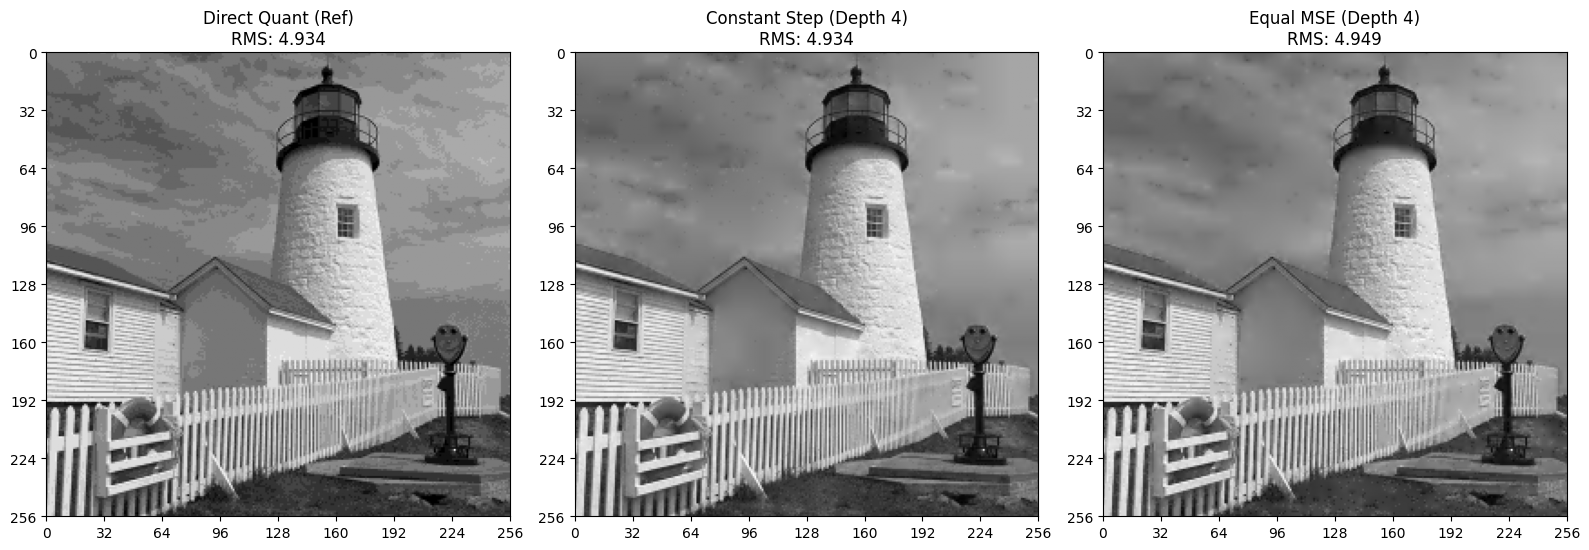

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar


# Ensure X is loaded and zero-mean (Run X = X - 128.0 if not done already)
h = 0.25 * np.array([1, 2, 1])

# ==========================================================
# 1. Establish the Reference Benchmark (Direct Quantisation)
# ==========================================================
ref_step = 17
X_ref_q = quantise(X, ref_step)
target_rms = np.std(X - X_ref_q)
bits_ref = X.size * bpp(X_ref_q)

print("=== 1. BASELINE REFERENCE ===")
print(f"Target RMS Error : {target_rms:.4f}")
print(f"Reference Bits   : {bits_ref:.1f} bits\n")

# ==========================================================
# 2. Equal MSE Impulse Response Measurement
# ==========================================================
Y0, Y1, Y2, Y3, X4 = py4enc(X, h)
layers = ['Y0', 'Y1', 'Y2', 'Y3', 'X4']
energies = {}

for layer in layers:
    t_Y0, t_Y1, t_Y2, t_Y3, t_X4 = [np.zeros_like(img) for img in [Y0, Y1, Y2, Y3, X4]]
    if layer == 'Y0':   t_Y0[t_Y0.shape[0]//2, t_Y0.shape[1]//2] = 100.0
    elif layer == 'Y1': t_Y1[t_Y1.shape[0]//2, t_Y1.shape[1]//2] = 100.0
    elif layer == 'Y2': t_Y2[t_Y2.shape[0]//2, t_Y2.shape[1]//2] = 100.0
    elif layer == 'Y3': t_Y3[t_Y3.shape[0]//2, t_Y3.shape[1]//2] = 100.0
    elif layer == 'X4': t_X4[t_X4.shape[0]//2, t_X4.shape[1]//2] = 100.0
        
    _, _, _, Z_out = py4dec(t_Y0, t_Y1, t_Y2, t_Y3, t_X4, h)
    energies[layer] = np.sum(Z_out**2.0)

step_ratios = {layer: np.sqrt(energies['Y0'] / energies[layer]) for layer in layers}

# ==========================================================
# 3. Optimization and Evaluation Engine
# ==========================================================
def evaluate_pyramid(depth, scheme='constant', return_image=False):
    ratios = {k: 1.0 for k in layers} if scheme == 'constant' else step_ratios
    X1 = rowdec(rowdec(X, h).T, h).T
    X2 = rowdec(rowdec(X1, h).T, h).T
    
    def get_metrics(base_q, output='rms'):
        q0, q1, q2 = base_q * ratios['Y0'], base_q * ratios['Y1'], base_q * ratios['Y2']
        q3, q4     = base_q * ratios['Y3'], base_q * ratios['X4']
        
        if depth == 1:
            q_X1, q_Y0 = quantise(X1, q1), quantise(Y0, q0)
            Z0 = rowint(rowint(q_X1, 2*h).T, 2*h).T + q_Y0
            bits = X1.size * bpp(q_X1) + Y0.size * bpp(q_Y0)
        elif depth == 2:
            q_X2, q_Y1, q_Y0 = quantise(X2, q2), quantise(Y1, q1), quantise(Y0, q0)
            Z1 = rowint(rowint(q_X2, 2*h).T, 2*h).T + q_Y1
            Z0 = rowint(rowint(Z1, 2*h).T, 2*h).T + q_Y0
            bits = X2.size * bpp(q_X2) + Y1.size * bpp(q_Y1) + Y0.size * bpp(q_Y0)
        elif depth == 4:
            q_Y0, q_Y1 = quantise(Y0, q0), quantise(Y1, q1)
            q_Y2, q_Y3, q_X4 = quantise(Y2, q2), quantise(Y3, q3), quantise(X4, q4)
            _, _, _, Z0 = py4dec(q_Y0, q_Y1, q_Y2, q_Y3, q_X4, h)
            bits = sum([img.size * bpp(q_img) for img, q_img in 
                        zip([Y0, Y1, Y2, Y3, X4], [q_Y0, q_Y1, q_Y2, q_Y3, q_X4])])
            
        if output == 'rms': return np.std(X - Z0)
        if output == 'bits': return bits
        if output == 'image': return Z0

    # Optimize to match target RMS
    res = minimize_scalar(lambda q: (get_metrics(q, 'rms') - target_rms)**2, bounds=(4.0, 25.0), method='bounded')
    opt_q = res.x
    
    if return_image:
        return get_metrics(opt_q, 'image')
    return opt_q, (bits_ref / get_metrics(opt_q, 'bits'))

# ==========================================================
# 4. Print Data Matrix
# ==========================================================
print("=== 2. COMPRESSION RATIOS (Matched to Target RMS) ===")
print("--- Constant Step Size ---")
for d in [1, 2, 4]:
    q_opt, cr = evaluate_pyramid(d, scheme='constant')
    print(f" Depth {d} | Opt Step: {q_opt:6.3f} | CR: {cr:.4f}")

print("\n--- Equal MSE ---")
for d in [1, 2, 4]:
    q_opt, cr = evaluate_pyramid(d, scheme='equal_mse')
    print(f" Depth {d} | Opt Base: {q_opt:6.3f} | CR: {cr:.4f}")

# ==========================================================
# 5. Visual Comparison Plots (Depth 4)
# ==========================================================
# Fetch the optimally matched images for the 4-layer systems
Z0_const = evaluate_pyramid(4, scheme='constant', return_image=True)
Z0_eqmse = evaluate_pyramid(4, scheme='equal_mse', return_image=True)

fig, axs = plt.subplots(1, 3, figsize=(16, 10))

# Top Row: Reconstructed Images
axs[0].set_title(f"Direct Quant (Ref)\nRMS: {target_rms:.3f}")
plot_image(X_ref_q, ax=axs[0])

axs[1].set_title(f"Constant Step (Depth 4)\nRMS: {np.std(X - Z0_const):.3f}")
plot_image(Z0_const, ax=axs[1])

axs[2].set_title(f"Equal MSE (Depth 4)\nRMS: {np.std(X - Z0_eqmse):.3f}")
plot_image(Z0_eqmse, ax=axs[2])

# Bottom Row: Error Residuals (Enhanced 3x for visibility)


plt.tight_layout()
plt.show()

In [66]:
# Find the step size ratios for equal MSE
import numpy as np


# Ensure X is loaded and zero-mean
h = 0.25 * np.array([1, 2, 1])

# 1. Run a quick forward pass just to clone the correct array shapes for each layer
Y0, Y1, Y2, Y3, X4 = py4enc(X, h)
layers = ['Y0', 'Y1', 'Y2', 'Y3', 'X4']
energies = {}

# 2. Perform the Impulse Response Measurement for each individual layer
for layer in layers:
    # Initialize an entirely blank pyramid of zeros
    t_Y0 = np.zeros_like(Y0)
    t_Y1 = np.zeros_like(Y1)
    t_Y2 = np.zeros_like(Y2)
    t_Y3 = np.zeros_like(Y3)
    t_X4 = np.zeros_like(X4)
    
    # Inject a central impulse of amplitude 100.0 into the active layer
    if layer == 'Y0':   t_Y0[Y0.shape[0]//2, Y0.shape[1]//2] = 100.0
    elif layer == 'Y1': t_Y1[Y1.shape[0]//2, Y1.shape[1]//2] = 100.0
    elif layer == 'Y2': t_Y2[Y2.shape[0]//2, Y2.shape[1]//2] = 100.0
    elif layer == 'Y3': t_Y3[Y3.shape[0]//2, t_Y3.shape[1]//2] = 100.0
    elif layer == 'X4': t_X4[X4.shape[0]//2, t_X4.shape[1]//2] = 100.0
        
    # Reconstruct back up to full image space (Z0)
    _, _, _, Z_out = py4dec(t_Y0, t_Y1, t_Y2, t_Y3, t_X4, h)
    
    # Measure the total energy (sum of squares) of the reconstructed output signal
    energies[layer] = np.sum(Z_out**2.0)

# 3. Calculate step size ratios relative to Y0
# Since q_i ∝ 1 / sqrt(E_i), the multiplier is sqrt(E_Y0 / E_i)
step_ratios = {layer: np.sqrt(energies['Y0'] / energies[layer]) for layer in layers}

# Display the clean results
print("--- EQUAL MSE RATIO DETERMINATION ---")
print("Measured Reconstructed Energies:")
for k, v in energies.items():
    print(f"  {k} Layer Impulse Energy : {v:10.2f}")

print("\nRequired Step Size Ratios (Multipliers relative to Y0):")
for k, v in step_ratios.items():
    print(f"  {k} Step Size Multiplier : {v:.4f}")

--- EQUAL MSE RATIO DETERMINATION ---
Measured Reconstructed Energies:
  Y0 Layer Impulse Energy :   10000.00
  Y1 Layer Impulse Energy :   22500.00
  Y2 Layer Impulse Energy :   75625.00
  Y3 Layer Impulse Energy :  288906.25
  X4 Layer Impulse Energy : 1142226.56

Required Step Size Ratios (Multipliers relative to Y0):
  Y0 Step Size Multiplier : 1.0000
  Y1 Step Size Multiplier : 0.6667
  Y2 Step Size Multiplier : 0.3636
  Y3 Step Size Multiplier : 0.1860
  X4 Step Size Multiplier : 0.0936


In [67]:
# Find the quantisation step size for equal mse, matching the reference RMS error


# Ensure X is loaded and zero-mean, and h is defined
h = 0.25 * np.array([1, 2, 1])

# ==========================================================
# 1. Establish the Target RMS Error from Direct Quantisation
# ==========================================================
X_ref_q = quantise(X, 17)
target_rms = np.std(X - X_ref_q)

print(f"Target Reference RMS Error (Direct step=17): {target_rms:.4f}\n")

# ==========================================================
# 2. Define the Equal MSE Pyramid RMS Evaluation Function
# ==========================================================
def get_equal_mse_pyramid_rms(base_q):
    """
    Encodes the image, applies step sizes scaled by the Equal MSE ratios,
    decodes the 4-layer pyramid, and returns the reconstructed RMS error.
    """
    # Forward 4-layer pyramid
    Y0, Y1, Y2, Y3, X4 = py4enc(X, h)
    
    # Scale the step sizes dynamically using our pre-calculated ratios
    q0 = base_q * step_ratios['Y0']
    q1 = base_q * step_ratios['Y1']
    q2 = base_q * step_ratios['Y2']
    q3 = base_q * step_ratios['Y3']
    q4 = base_q * step_ratios['X4']
    
    # Quantise all components with their respective optimized step sizes
    Y0_q = quantise(Y0, q0)
    Y1_q = quantise(Y1, q1)
    Y2_q = quantise(Y2, q2)
    Y3_q = quantise(Y3, q3)
    X4_q = quantise(X4, q4)
    
    # Reconstruct back up to spatial full size Z0
    _, _, _, Z0 = py4dec(Y0_q, Y1_q, Y2_q, Y3_q, X4_q, h)
    
    return np.std(X - Z0)

# ==========================================================
# 3. Execute the Scalar Bounded Optimization
# ==========================================================
# The objective is to make the squared difference between trial RMS and target RMS zero
objective = lambda q: (get_equal_mse_pyramid_rms(q) - target_rms) ** 2

# Search safely for the base step size
result = minimize_scalar(objective, bounds=(4.0, 20.0), method='bounded')
opt_base_q = result.x

# ==========================================================
# 4. Calculate and Display the Final Target Step Sizes
# ==========================================================
print("--- OPTIMIZED EQUAL MSE STEP SIZES ---")
print(f"Optimized Base Step Size (for Y0): {opt_base_q:.4f}\n")
print("Resulting Step Sizes per Layer to match Target Quality:")
for layer in layers:
    actual_step = opt_base_q * step_ratios[layer]
    print(f"  {layer} Layer Quantisation Step Size : {actual_step:.4f}")

Target Reference RMS Error (Direct step=17): 4.9340

--- OPTIMIZED EQUAL MSE STEP SIZES ---
Optimized Base Step Size (for Y0): 18.3762

Resulting Step Sizes per Layer to match Target Quality:
  Y0 Layer Quantisation Step Size : 18.3762
  Y1 Layer Quantisation Step Size : 12.2508
  Y2 Layer Quantisation Step Size : 6.6823
  Y3 Layer Quantisation Step Size : 3.4188
  X4 Layer Quantisation Step Size : 1.7194


In [68]:
# Find the compression ratios for equal mse

# Ensure X is loaded and zero-mean, and h and step_ratios are defined
h = 0.25 * np.array([1, 2, 1])

# ==========================================================
# 1. Establish the Reference Benchmark (Direct Quantisation)
# ==========================================================
X_ref_q = quantise(X, 17)
bits_ref = X.size * bpp(X_ref_q)
target_rms = np.std(X - X_ref_q)

# ==========================================================
# 2. Define Function to Reconstruct and Measure RMS for Equal MSE
# ==========================================================
def get_equal_mse_rms(test_base_q, depth):
    """
    Encodes, quantises using Equal MSE scaled steps, and decodes the pyramid
    up to a specified layer depth to calculate the reconstructed RMS error.
    """
    Y0, Y1, Y2, Y3, X4 = py4enc(X, h)
    
    # Apply the pre-calculated ratios to the trial base step size
    q0 = test_base_q * step_ratios['Y0']
    q1 = test_base_q * step_ratios['Y1']
    q2 = test_base_q * step_ratios['Y2']
    q3 = test_base_q * step_ratios['Y3']
    q4 = test_base_q * step_ratios['X4']
    
    if depth == 1:
        X1 = rowdec(rowdec(X, h).T, h).T
        Z0 = rowint(rowint(quantise(X1, q1), 2*h).T, 2*h).T + quantise(Y0, q0)
    elif depth == 2:
        X1 = rowdec(rowdec(X, h).T, h).T
        X2 = rowdec(rowdec(X1, h).T, h).T
        Z1 = rowint(rowint(quantise(X2, q2), 2*h).T, 2*h).T + quantise(Y1, q1)
        Z0 = rowint(rowint(Z1, 2*h).T, 2*h).T + quantise(Y0, q0)
    elif depth == 4:
        Y0_q = quantise(Y0, q0)
        Y1_q = quantise(Y1, q1)
        Y2_q = quantise(Y2, q2)
        Y3_q = quantise(Y3, q3)
        X4_q = quantise(X4, q4)
        _, _, _, Z0 = py4dec(Y0_q, Y1_q, Y2_q, Y3_q, X4_q, h)
        
    return np.std(X - Z0)

# ==========================================================
# 3. Loop Through Depths, Optimize Base Step Size, and Calculate CR
# ==========================================================
print("--- EQUAL MSE PYRAMID RESULTS (MATCHED TO REFERENCE RMS) ---")
depths = [1, 2, 4]

for d in depths:
    # Set up the objective function to minimize the distance to our target RMS
    objective = lambda q: (get_equal_mse_rms(q, d) - target_rms) ** 2
    
    # Run the scalar optimization to find the matching base step size
    res = minimize_scalar(objective, bounds=(4.0, 20.0), method='bounded')
    opt_base_q = res.x
    
    # Calculate scaled steps for this depth
    q0 = opt_base_q * step_ratios['Y0']
    q1 = opt_base_q * step_ratios['Y1']
    q2 = opt_base_q * step_ratios['Y2']
    q3 = opt_base_q * step_ratios['Y3']
    q4 = opt_base_q * step_ratios['X4']
    
    Y0, Y1, Y2, Y3, X4 = py4enc(X, h)
    
    if d == 1:
        X1 = rowdec(rowdec(X, h).T, h).T
        total_bits = (Y0.size * bpp(quantise(Y0, q0)) + 
                      X1.size * bpp(quantise(X1, q1)))
    elif d == 2:
        X1 = rowdec(rowdec(X, h).T, h).T
        X2 = rowdec(rowdec(X1, h).T, h).T
        total_bits = (Y0.size * bpp(quantise(Y0, q0)) + 
                      Y1.size * bpp(quantise(Y1, q1)) + 
                      X2.size * bpp(quantise(X2, q2)))
    elif d == 4:
        total_bits = (Y0.size * bpp(quantise(Y0, q0)) + 
                      Y1.size * bpp(quantise(Y1, q1)) + 
                      Y2.size * bpp(quantise(Y2, q2)) + 
                      Y3.size * bpp(quantise(Y3, q3)) + 
                      X4.size * bpp(quantise(X4, q4)))
    
    # Calculate the compression ratio
    cr = bits_ref / total_bits
    
    print(f"Layers: {d} | Opt Base Step (Y0): {opt_base_q:6.3f} | Compression Ratio: {cr:.4f}")

--- EQUAL MSE PYRAMID RESULTS (MATCHED TO REFERENCE RMS) ---
Layers: 1 | Opt Base Step (Y0): 18.906 | Compression Ratio: 1.4113
Layers: 2 | Opt Base Step (Y0): 18.812 | Compression Ratio: 1.5595
Layers: 4 | Opt Base Step (Y0): 18.376 | Compression Ratio: 1.5699


## 6.3 Changing the decimation / interpolation filter
It is also worth investigating whether a more complicated decimation / interpolation filter **h** can improve the compression. The z-transfer function of the filter used so far is

$$ h(z) = \left(\frac{1 + z^{-1}}{2}\right)^m $$

where $m = 2$. If $m$ is increased to 4(so the number of taps remains odd), the vector representation of **h** is \[1/16 4/16 6/16 4/16 1/16\]. This filter has a lower cut-off frequency than when $m=2$, so you should find that each interpolated lowpass image in the pyramid is a little more blurred, and there is a little more energy left in each highpass image.

<div class="alert alert-block alert-danger">
Optimise the step sizes for the pyramid with this new filter and determine the new compression performance and visual features.
</div>

CR with m=2 Filter: 3.5935
CR with m=4 Filter: 3.2857


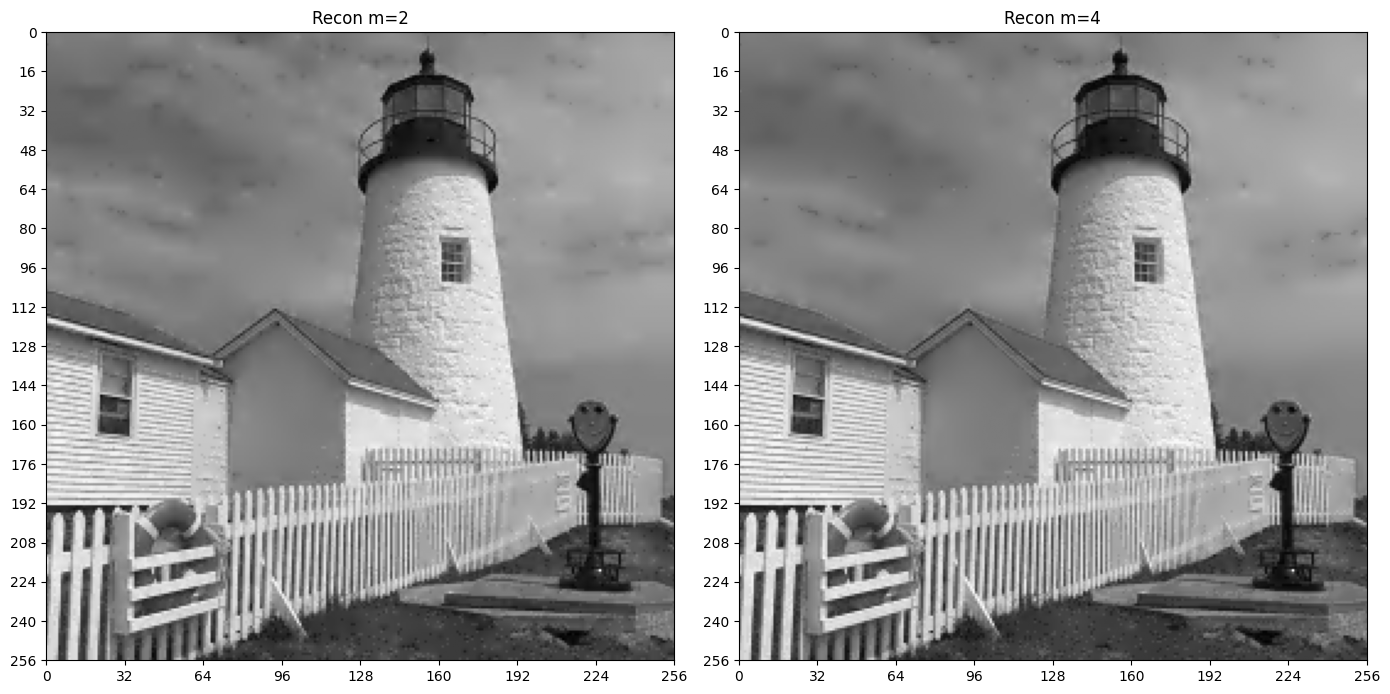

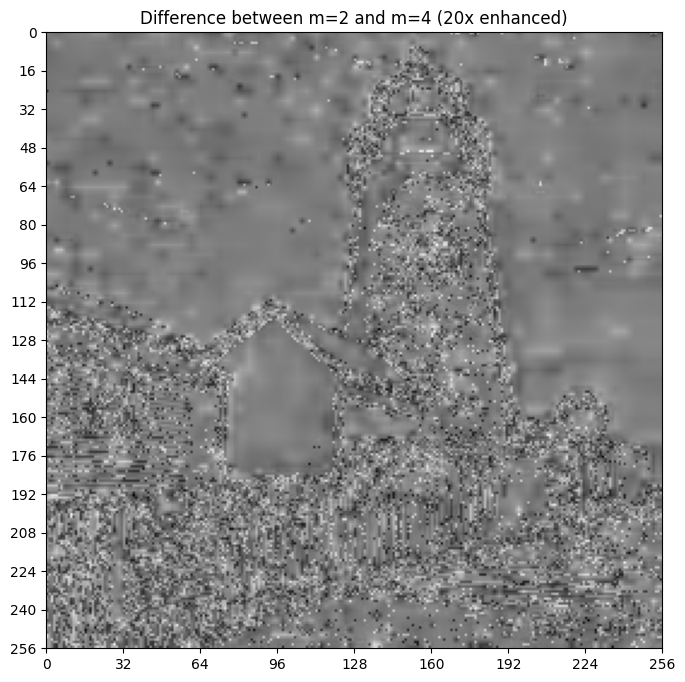

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar


# Pre-computation: Define filters
h_m2 = 0.25 * np.array([1, 2, 1])
h_m4 = np.array([1, 4, 6, 4, 1]) / 16.0

def get_impulse_ratios(h):
    Y0, Y1, Y2, Y3, X4 = py4enc(X, h)
    layers = ['Y0', 'Y1', 'Y2', 'Y3', 'X4']
    energies = {}
    for layer in layers:
        t_pyr = [np.zeros_like(img) for img in [Y0, Y1, Y2, Y3, X4]]
        # Inject 100.0 at center of specified layer
        idx = {'Y0':0, 'Y1':1, 'Y2':2, 'Y3':3, 'X4':4}[layer]
        t_pyr[idx][t_pyr[idx].shape[0]//2, t_pyr[idx].shape[1]//2] = 100.0
        _, _, _, Z_out = py4dec(*t_pyr, h)
        energies[layer] = np.sum(Z_out**2.0)
    return {layer: np.sqrt(energies['Y0'] / energies[layer]) for layer in layers}

def evaluate_pyramid(depth, h, scheme='equal_mse', return_image=False):
    ratios = get_impulse_ratios(h) if scheme == 'equal_mse' else {k: 1.0 for k in ['Y0', 'Y1', 'Y2', 'Y3', 'X4']}
    # Target RMS from Reference (Direct quant step 17)
    target_rms = 4.9340 
    
    def get_metrics(base_q, return_type='rms'):
        # Apply multipliers
        q = {k: base_q * ratios[k] for k in ratios}
        Y0, Y1, Y2, Y3, X4 = py4enc(X, h)
        
        # Simple reconstruction logic for Depth 4
        _, _, _, Z0 = py4dec(quantise(Y0, q['Y0']), quantise(Y1, q['Y1']), 
                             quantise(Y2, q['Y2']), quantise(Y3, q['Y3']), 
                             quantise(X4, q['X4']), h)
        
        if return_type == 'rms': return np.std(X - Z0)
        if return_type == 'bits': return sum([i.size * bpp(quantise(i, q[k])) for i, k in zip([Y0, Y1, Y2, Y3, X4], ['Y0', 'Y1', 'Y2', 'Y3', 'X4'])])
        return Z0

    opt_base_q = minimize_scalar(lambda q: (get_metrics(q, 'rms') - target_rms)**2, bounds=(4.0, 30.0), method='bounded').x
    if return_image: return get_metrics(opt_base_q, 'image')
    return (X.size * 8.0) / get_metrics(opt_base_q, 'bits') # CR relative to raw 8-bit

# --- RUN ANALYSIS ---
cr_m2 = evaluate_pyramid(4, h_m2, 'equal_mse')
cr_m4 = evaluate_pyramid(4, h_m4, 'equal_mse')
Z0_m2 = evaluate_pyramid(4, h_m2, 'equal_mse', return_image=True)
Z0_m4 = evaluate_pyramid(4, h_m4, 'equal_mse', return_image=True)

print(f"CR with m=2 Filter: {cr_m2:.4f}")
print(f"CR with m=4 Filter: {cr_m4:.4f}")

# --- PLOTTING ---
# --- PLOTTING ---
fig, axs = plt.subplots(1, 2, figsize=(14, 10))

# M=2 Filter Visuals
plot_image(Z0_m2, ax=axs[ 0])
axs[0].set_title("Recon m=2")


# M=4 Filter Visuals
plot_image(Z0_m4, ax=axs[1])
axs[1].set_title("Recon m=4")



plt.tight_layout()
plt.show()

# Create a "difference" image to see where the filters diverge
# Multiply by 10 or 20 to make the subtle differences visible
diff_image = (Z0_m2 - Z0_m4) * 20.0 

# Create a "difference" image to see where the filters diverge
diff_image = (Z0_m2 - Z0_m4) * 20.0 

plt.figure(figsize=(8, 8))
plot_image(diff_image)
plt.title("Difference between m=2 and m=4 (20x enhanced)")
plt.show()

# First Interim Report
Discuss and explain your results, gathered so far, in your first interim report. Try to answer the questions posed in the above test. Be brief where things are straightforward, but pay more attention to detail in areas where you think something interesting is happening. Write this as a standalone report, not as a series of bullet points answering the questions posed.